<a href="https://colab.research.google.com/github/MD-Danish01/tf-sin-function/blob/main/TFsinwavetrain.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
%tensorflow_version 2.1

Colab only includes TensorFlow 2.x; %tensorflow_version has no effect.


In [3]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import math
from tensorflow.keras import layers

In [8]:
# print versions
!python --version
print("numpy" + np.__version__)
print("tensorflow"+tf.__version__)
print("keras"+tf.keras.__version__)


Python 3.12.13
numpy2.0.2
tensorflow2.20.0
keras3.13.2


In [9]:
#settings

nsample = 1000 #number of sample to use as a dataset
val_ratio = 0.2 #persentage of samples that should be held for validation set
test_ratio = 0.2 #persentage of samples that should be held for test set
tflite_model_name = "sin_model" #will be given .tffile suffix
c_model_name = "sin_model" #will be given .h suffix

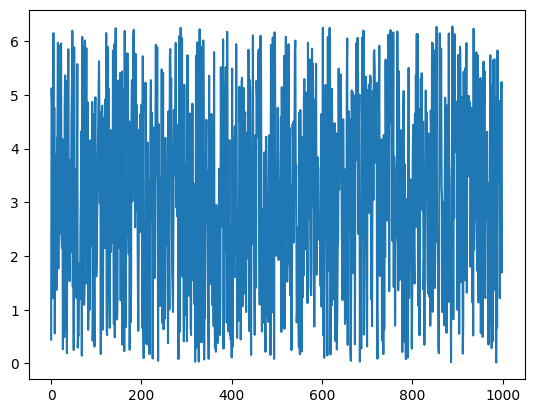

In [10]:
#Generate some random samples
np.random.seed(4321)
x_values = np.random.uniform(low=0, high=2*math.pi, size=nsample)
plt.plot(x_values)

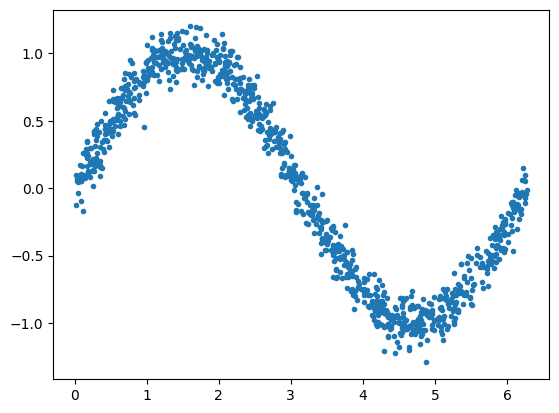

In [11]:
#creat a noicy sinwave with these values
y_values = np.sin(x_values) + (0.1 * np.random.randn(x_values.shape[0]))
plt.plot(x_values,y_values,".")

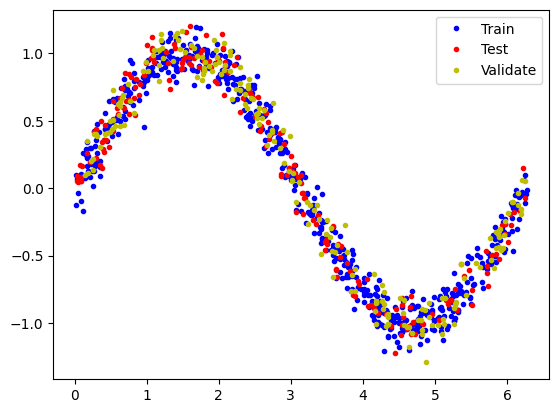

In [12]:
# plit the dataset into training, validation and test sets
val_split = int(val_ratio * nsample)
test_split = int(val_split + (test_ratio * nsample))
x_val, x_test, x_train = np.split(x_values,[val_split,test_split])
y_val, y_test, y_train = np.split(y_values,[val_split,test_split])

# Check that our splits add up correctly
assert(x_train.size + x_val.size + x_test.size) == nsample

# plot the data in each partition in different colors
plt.plot(x_train, y_train, 'b.', label="Train")
plt.plot(x_test, y_test, 'r.', label="Test")
plt.plot(x_val, y_val, 'y.', label="Validate")
plt.legend()
plt.show()

In [13]:
# Creat a model
model = tf.keras.Sequential()
model.add(layers.Dense(16, activation='relu', input_shape=(1,)))
model.add(layers.Dense(16, activation='relu'))
model.add(layers.Dense(1))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [14]:
# View model
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │            32 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 321 (1.25 KB)

 Trainable params: 321 (1.25 KB)

 Non-trainable params: 0 (0.00 B)

In [15]:
# Add optimizer, loss fungtion and metrics to model and compile it
model.compile(optimizer='rmsprop', loss='mae', metrics=['mae'])

In [16]:
# Train model
history = model.fit(x_train,
                    y_train,
                    epochs=500,
                    batch_size=100,
                    validation_data=(x_val, y_val))

Epoch 1/500
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 47ms/step - loss: 0.6267 - mae: 0.6267 - val_loss: 0.6014 - val_mae: 0.6014
Epoch 2/500
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.5473 - mae: 0.5473 - val_loss: 0.5852 - val_mae: 0.5852
Epoch 3/500
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.5308 - mae: 0.5308 - val_loss: 0.5691 - val_mae: 0.5691
Epoch 4/500
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.5209 - mae: 0.5209 - val_loss: 0.5758 - val_mae: 0.5758
Epoch 5/500
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.5105 - mae: 0.5105 - val_loss: 0.5523 - val_mae: 0.5523
Epoch 6/500
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.5029 - mae: 0.5029 - val_loss: 0.5393 - val_mae: 0.5393
Epoch 7/500
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.4956 - mae: 0.4956 - val_loss: 0.5435 - val_mae: 0.5435
Epoch 8/500
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.4875 - mae: 0.4875 - val_loss: 0.5255 - val_mae: 0.5255
Epoch 9/500
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.4792 - mae: 

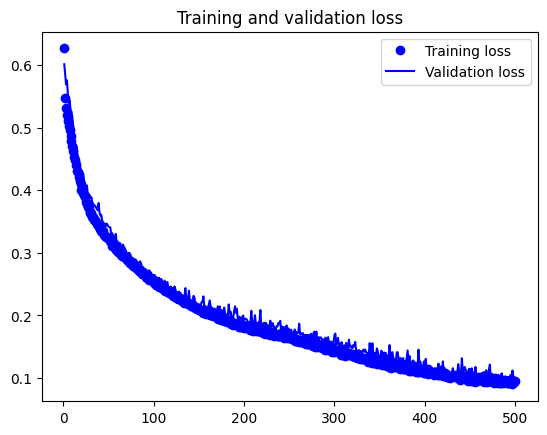

In [17]:
# Plot the training history
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(1, len(loss) + 1)

plt.plot(epochs, loss, 'bo', label='Training loss')
plt.plot(epochs, val_loss, 'b', label='Validation loss')
plt.title('Training and validation loss')
plt.legend()

plt.show()

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step


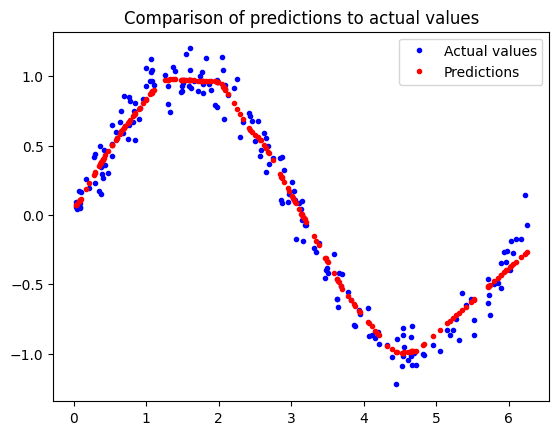

In [18]:
# Plot predictions against actual values
predictions = model.predict(x_test)
plt.clf()
plt.title('Comparison of predictions to actual values')
plt.plot(x_test, y_test, 'b.', label='Actual values')
plt.plot(x_test, predictions, 'r.', label='Predictions')
plt.legend()
plt.show()

In [19]:
# convert keras model to tfile model
converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.OPTIMIZE_FOR_SIZE]
tflite_model = converter.convert()

open(tflite_model_name + ".tflite", "wb").write(tflite_model)

Saved artifact at '/tmp/tmp1ptls16h'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 1), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  137530903776144: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137530903777296: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137530903776528: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137530903774608: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137530903774224: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137530903774992: TensorSpec(shape=(), dtype=tf.resource, name=None)


3164

In [20]:
# Funnction: Convert some hex value into an array for C programming
def hex_to_c_array(hex_data, var_name) :

  c_str = ''

  #creat a heder guard
  c_str += '#ifndef ' + var_name.upper() + '_H\n'
  c_str += '#define ' + var_name.upper() + '_H\n\n'

  # Add array length at the top of file
  c_str += '\nunsigned int ' + var_name + '_len = ' + str(len(hex_data)) + ';\n'

  # Declare C variable
  c_str += 'unsigned char ' + var_name + '[] = {'
  hex_array = []
  for i, val in enumerate(hex_data) :

    # Construct string from hex
    hex_str = format(val, '#04x')

    # Add formating to each line stays within 80 characters
    if((i + 1) < len(hex_data)) :
      hex_str += ','
    if((i + 1) % 12 == 0) :
      hex_str += '\n '
    hex_array.append(hex_str)

  # Adding closing brace
  c_str += '\n ' + format(' '.join(hex_array)) + '\n};\n\n'

  # Close out header guard
  c_str += '#endif //' + var_name.upper() + '_H'

  return c_str

In [21]:
# write TFLite model to a C source (or header) file
with open(c_model_name + '.h', 'w') as file :
  file.write(hex_to_c_array(tflite_model, c_model_name))